# Cross-Pipeline Comparison: MediaPipe vs MMPose, 2D vs 3D

This notebook performs the final cross-pipeline comparison between:

- MediaPipe 2D
- MediaPipe 3D
- MMPose 2D
- MMPose 3D

It uses a unified evaluation protocol to compare feature quality, model performance,
and 2D vs 3D representations.

This notebook is also used to train and export the final MediaPipe MLP models
used in the application.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MP_VIDEO_PATH = PROCESSED_DIR / "pushup_video_level_features.csv"
MMPOSE_2D_PATH = PROCESSED_DIR / "mmpose_2d_features_video_level.csv"
MMPOSE_3D_PATH = PROCESSED_DIR / "mmpose_3d_features_video_level.csv"

print("Processed dir:", PROCESSED_DIR)
print("MediaPipe video-level:", MP_VIDEO_PATH)
print("MMPose 2D video-level:", MMPOSE_2D_PATH)
print("MMPose 3D video-level:", MMPOSE_3D_PATH)

mp_df = pd.read_csv(MP_VIDEO_PATH)
mm2d_df = pd.read_csv(MMPOSE_2D_PATH)
mm3d_df = pd.read_csv(MMPOSE_3D_PATH)

print("MediaPipe shape:", mp_df.shape)
print("MMPose 2D shape:", mm2d_df.shape)
print("MMPose 3D shape:", mm3d_df.shape)


Processed dir: C:\Users\sebas\Documents\master_ai\05_dne\AI-Gym\AI-Gym\posture_checker_offline\data\processed
MediaPipe video-level: C:\Users\sebas\Documents\master_ai\05_dne\AI-Gym\AI-Gym\posture_checker_offline\data\processed\pushup_video_level_features.csv
MMPose 2D video-level: C:\Users\sebas\Documents\master_ai\05_dne\AI-Gym\AI-Gym\posture_checker_offline\data\processed\mmpose_2d_features_video_level.csv
MMPose 3D video-level: C:\Users\sebas\Documents\master_ai\05_dne\AI-Gym\AI-Gym\posture_checker_offline\data\processed\mmpose_3d_features_video_level.csv
MediaPipe shape: (100, 42)
MMPose 2D shape: (100, 7)
MMPose 3D shape: (100, 7)


In [3]:
def first_existing(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"None of these columns were found: {candidates}")


def get_target_column(df):
    return first_existing(df, ["label_first", "label", "true_label", "true_label_video"])


def get_video_column(df):
    candidates = ["video_name", "video", "file_name", "sample_id"]
    for col in candidates:
        if col in df.columns:
            return col
    return None


def build_mediapipe_representation(df, modality="2d"):
    target_col = get_target_column(df)
    video_col = get_video_column(df)
    suffix = modality.lower()

    feature_map = {
        "elbow_mean": [
            f"elbow_angle_{suffix}_smooth_mean",
            f"elbow_angle_{suffix}_mean",
        ],
        "elbow_std": [
            f"elbow_angle_{suffix}_smooth_std",
            f"elbow_angle_{suffix}_std",
        ],
        "body_mean": [
            f"body_alignment_angle_{suffix}_smooth_mean",
            f"body_alignment_angle_{suffix}_mean",
        ],
        "hip_mean": [
            f"hip_angle_{suffix}_smooth_mean",
            f"hip_angle_{suffix}_mean",
        ],
    }

    selected_cols = {name: first_existing(df, candidates) for name, candidates in feature_map.items()}
    cols_to_keep = [target_col] + list(selected_cols.values())
    if video_col is not None:
        cols_to_keep = [video_col] + cols_to_keep

    out = df[cols_to_keep].copy()
    rename_map = {v: k for k, v in selected_cols.items()}
    rename_map[target_col] = "label"
    if video_col is not None:
        rename_map[video_col] = "video_id"
    out = out.rename(columns=rename_map)

    return out


def build_mmpose_representation(df):
    target_col = get_target_column(df)
    video_col = get_video_column(df)

    cols = ["elbow_angle_mean", "elbow_angle_std", "body_alignment_angle_mean", "hip_angle_mean", target_col]
    if video_col is not None:
        cols = [video_col] + cols

    out = df[cols].copy()
    out = out.rename(columns={
        "elbow_angle_mean": "elbow_mean",
        "elbow_angle_std": "elbow_std",
        "body_alignment_angle_mean": "body_mean",
        "hip_angle_mean": "hip_mean",
        target_col: "label",
        **({video_col: "video_id"} if video_col is not None else {}),
    })
    return out


In [4]:
datasets = {
    "MediaPipe 2D": build_mediapipe_representation(mp_df, modality="2d"),
    "MediaPipe 3D": build_mediapipe_representation(mp_df, modality="3d"),
    "MMPose 2D": build_mmpose_representation(mm2d_df),
    "MMPose 3D": build_mmpose_representation(mm3d_df),
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.head())



MediaPipe 2D
  video_id      label  elbow_mean  elbow_std   body_mean    hip_mean
0    1.mp4  incorrect  131.529385  50.035481  162.169565  168.502743
1   10.mp4  incorrect  143.709620  47.922323  169.437764  171.417330
2   11.mp4  incorrect  124.318309  61.609328  161.906366  174.710849
3   12.mp4  incorrect  140.166148  52.029299  169.852325  165.900209
4   13.mp4  incorrect  116.396072  53.141496  162.920529  170.296922

MediaPipe 3D
  video_id      label  elbow_mean  elbow_std   body_mean    hip_mean
0    1.mp4  incorrect  132.993026  26.328173  158.766623  163.028666
1   10.mp4  incorrect  122.130830  29.776975  163.943309  165.067001
2   11.mp4  incorrect  117.440292  38.226489  159.207029  168.018351
3   12.mp4  incorrect  121.826055  29.163012  161.849822  158.387201
4   13.mp4  incorrect  111.174759  27.441589  160.207832  166.800187

MMPose 2D
  video_id  elbow_mean  elbow_std  body_mean  hip_mean      label
0        1    0.606726   0.325572   0.503093  0.561281  incorrect
1

In [5]:
def dataset_summary(name, df):
    feature_cols = ["elbow_mean", "elbow_std", "body_mean", "hip_mean"]
    label_counts = df["label"].value_counts(dropna=False).to_dict()
    return {
        "Representation": name,
        "Videos": len(df),
        "Features used": len(feature_cols),
        "Mean missing ratio": df[feature_cols].isna().mean().mean(),
        "Median missing ratio": df[feature_cols].isna().mean().median(),
        "Correct videos": label_counts.get("correct", 0),
        "Incorrect videos": label_counts.get("incorrect", 0),
    }

coverage_df = pd.DataFrame([dataset_summary(name, df) for name, df in datasets.items()])
display(coverage_df)


,Representation,Videos,Features used,Mean missing ratio,Median missing ratio,Correct videos,Incorrect videos
0,MediaPipe 2D,100,4,0.0,0.0,50,50
1,MediaPipe 3D,100,4,0.0,0.0,50,50
2,MMPose 2D,100,4,0.0,0.0,50,50
3,MMPose 3D,100,4,0.0,0.0,50,50


In [6]:
def cohens_d(x_correct, x_incorrect):
    x1 = pd.Series(x_correct).dropna().astype(float)
    x0 = pd.Series(x_incorrect).dropna().astype(float)
    if len(x1) < 2 or len(x0) < 2:
        return np.nan
    s1 = x1.std(ddof=1)
    s0 = x0.std(ddof=1)
    pooled = np.sqrt(((len(x1) - 1) * s1**2 + (len(x0) - 1) * s0**2) / (len(x1) + len(x0) - 2))
    if pooled == 0:
        return np.nan
    return (x1.mean() - x0.mean()) / pooled


separability_rows = []
for name, df in datasets.items():
    correct_df = df[df["label"] == "correct"]
    incorrect_df = df[df["label"] == "incorrect"]
    for col in ["elbow_mean", "elbow_std", "body_mean", "hip_mean"]:
        separability_rows.append({
            "Representation": name,
            "Feature": col,
            "Mean(correct)": correct_df[col].mean(),
            "Mean(incorrect)": incorrect_df[col].mean(),
            "Cohen_d": cohens_d(correct_df[col], incorrect_df[col]),
        })

separability_df = pd.DataFrame(separability_rows)
display(separability_df.sort_values(["Representation", "Cohen_d"], ascending=[True, False]))


,Representation,Feature,Mean(correct),Mean(incorrect),Cohen_d
9,MMPose 2D,elbow_std,0.363508,0.327805,0.733120
10,MMPose 2D,body_mean,0.562944,0.508153,0.525959
11,MMPose 2D,hip_mean,0.511312,0.533369,-0.212361
8,MMPose 2D,elbow_mean,0.638916,0.662571,-0.270821
13,MMPose 3D,elbow_std,0.346229,0.294469,0.957029
12,MMPose 3D,elbow_mean,0.571607,0.499735,0.718779
14,MMPose 3D,body_mean,0.332563,0.300905,0.362966
15,MMPose 3D,hip_mean,0.292176,0.364881,-0.990982
2,MediaPipe 2D,body_mean,173.610829,157.701639,1.907456
3,MediaPipe 2D,hip_mean,170.909940,162.949034,0.839594


In [7]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="correct", zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label="correct", zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label="correct", zero_division=0),
    }


def benchmark_representation(name, df):
    feature_cols = ["elbow_mean", "elbow_std", "body_mean", "hip_mean"]
    work_df = df.copy()

    X = work_df[feature_cols]
    y = work_df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        "Logistic regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]),
        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)),
        ]),
    }

    rows = []
    fitted_models = {}
    test_splits = {}

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1_macro",
    }

    for model_name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        metrics = compute_metrics(y_test, y_pred)

        cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)

        rows.append({
            "Representation": name,
            "Model": model_name,
            "Test accuracy": metrics["accuracy"],
            "Test balanced accuracy": metrics["balanced_accuracy"],
            "Test precision": metrics["precision"],
            "Test recall": metrics["recall"],
            "Test F1": metrics["f1"],
            "CV accuracy mean": cv_results["test_accuracy"].mean(),
            "CV accuracy std": cv_results["test_accuracy"].std(),
            "CV balanced accuracy mean": cv_results["test_balanced_accuracy"].mean(),
            "CV F1 mean": cv_results["test_f1"].mean(),
        })

        fitted_models[model_name] = pipeline
        test_splits[model_name] = (X_test, y_test, y_pred)

    return pd.DataFrame(rows), fitted_models, test_splits


In [8]:
benchmark_tables = []
fitted_registry = {}
test_registry = {}

for name, df in datasets.items():
    table, fitted_models, test_splits = benchmark_representation(name, df)
    benchmark_tables.append(table)
    fitted_registry[name] = fitted_models
    test_registry[name] = test_splits

benchmark_df = pd.concat(benchmark_tables, ignore_index=True)
display(benchmark_df.sort_values(["Model", "CV accuracy mean"], ascending=[True, False]))


,Representation,Model,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,CV accuracy mean,CV accuracy std,CV balanced accuracy mean,CV F1 mean
0,MediaPipe 2D,Logistic regression,0.90,0.90,0.900000,0.9,0.900000,0.91,0.058310,0.91,0.909825
2,MediaPipe 3D,Logistic regression,0.90,0.90,0.900000,0.9,0.900000,0.88,0.060000,0.88,0.879799
6,MMPose 3D,Logistic regression,0.85,0.85,0.888889,0.8,0.842105,0.75,0.054772,0.75,0.747623
4,MMPose 2D,Logistic regression,0.65,0.65,0.615385,0.8,0.695652,0.69,0.073485,0.69,0.687690
1,MediaPipe 2D,MLP,0.95,0.95,1.000000,0.9,0.947368,0.94,0.037417,0.94,0.939950
3,MediaPipe 3D,MLP,0.90,0.90,0.900000,0.9,0.900000,0.86,0.037417,0.86,0.857366
7,MMPose 3D,MLP,0.85,0.85,0.818182,0.9,0.857143,0.80,0.094868,0.80,0.798270
5,MMPose 2D,MLP,0.75,0.75,0.692308,0.9,0.782609,0.61,0.086023,0.61,0.607938


In [9]:
summary_table = benchmark_df.pivot(index="Representation", columns="Model", values=["Test accuracy", "CV accuracy mean", "CV balanced accuracy mean", "CV F1 mean"])
display(summary_table)


Test accuracy          CV accuracy mean        \
Model          Logistic regression   MLP Logistic regression   MLP   
Representation                                                       
MMPose 2D                     0.65  0.75                0.69  0.61   
MMPose 3D                     0.85  0.85                0.75  0.80   
MediaPipe 2D                  0.90  0.95                0.91  0.94   
MediaPipe 3D                  0.90  0.90                0.88  0.86   

               CV balanced accuracy mean                CV F1 mean            
Model                Logistic regression   MLP Logistic regression       MLP  
Representation                                                                
MMPose 2D                           0.69  0.61            0.687690  0.607938  
MMPose 3D                           0.75  0.80            0.747623  0.798270  
MediaPipe 2D                        0.91  0.94            0.909825  0.939950  
MediaPipe 3D                        0.88  0.86            0.879799  0.857366

In [10]:
best_rows = (
    benchmark_df.sort_values(["Representation", "CV accuracy mean"], ascending=[True, False])
    .groupby("Representation")
    .head(1)
    .reset_index(drop=True)
)
display(best_rows)


,Representation,Model,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,CV accuracy mean,CV accuracy std,CV balanced accuracy mean,CV F1 mean
0,MMPose 2D,Logistic regression,0.65,0.65,0.615385,0.8,0.695652,0.69,0.073485,0.69,0.687690
1,MMPose 3D,MLP,0.85,0.85,0.818182,0.9,0.857143,0.80,0.094868,0.80,0.798270
2,MediaPipe 2D,MLP,0.95,0.95,1.000000,0.9,0.947368,0.94,0.037417,0.94,0.939950
3,MediaPipe 3D,Logistic regression,0.90,0.90,0.900000,0.9,0.900000,0.88,0.060000,0.88,0.879799


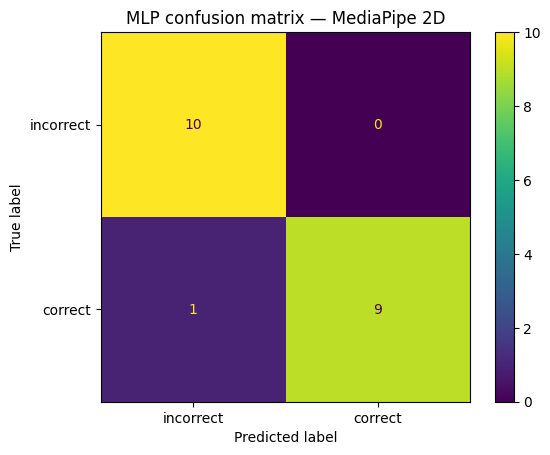

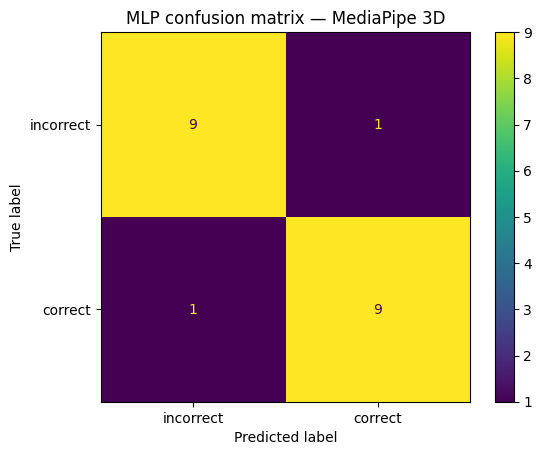

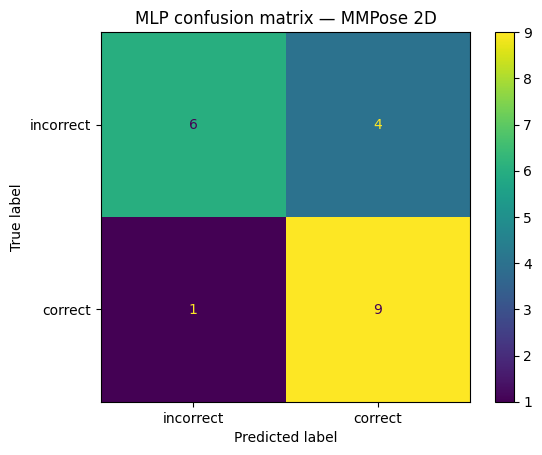

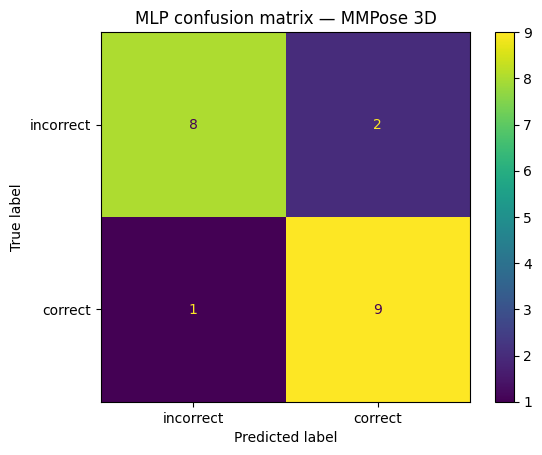

In [11]:
def plot_confusion_for(name, model_name):
    X_test, y_test, y_pred = test_registry[name][model_name]
    cm = confusion_matrix(y_test, y_pred, labels=["incorrect", "correct"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["incorrect", "correct"])
    disp.plot()
    plt.title(f"{model_name} confusion matrix — {name}")
    plt.show()


# Example: inspect the strongest non-linear model on each representation.
for representation in datasets.keys():
    plot_confusion_for(representation, "MLP")


In [12]:
compare_2d_vs_3d_df = (
    best_rows.assign(
        Pipeline=lambda d: d["Representation"].str.split().str[0],
        Dimension=lambda d: d["Representation"].str.split().str[1],
    )
    [["Pipeline", "Dimension", "Model", "CV accuracy mean", "CV balanced accuracy mean", "CV F1 mean"]]
    .sort_values(["Pipeline", "Dimension"])
)

display(compare_2d_vs_3d_df)


,Pipeline,Dimension,Model,CV accuracy mean,CV balanced accuracy mean,CV F1 mean
0,MMPose,2D,Logistic regression,0.69,0.69,0.687690
1,MMPose,3D,MLP,0.80,0.80,0.798270
2,MediaPipe,2D,MLP,0.94,0.94,0.939950
3,MediaPipe,3D,Logistic regression,0.88,0.88,0.879799


In [13]:
mediapipe_vs_mmpose_df = (
    best_rows.assign(
        Pipeline=lambda d: d["Representation"].str.split().str[0],
        Dimension=lambda d: d["Representation"].str.split().str[1],
    )
    .pivot(index="Dimension", columns="Pipeline", values=["CV accuracy mean", "CV balanced accuracy mean", "CV F1 mean"])
)

display(mediapipe_vs_mmpose_df)


CV accuracy mean           CV balanced accuracy mean            \
Pipeline            MMPose MediaPipe                    MMPose MediaPipe   
Dimension                                                                  
2D                    0.69      0.94                      0.69      0.94   
3D                    0.80      0.88                      0.80      0.88   

          CV F1 mean            
Pipeline      MMPose MediaPipe  
Dimension                       
2D           0.68769  0.939950  
3D           0.79827  0.879799

## Final model export

Based on the comparison results, we export the MediaPipe MLP models
(2D and 3D) for downstream use in the application.

In [14]:
import joblib
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Final feature set used for deployment
feature_cols = ["elbow_mean", "elbow_std", "body_mean", "hip_mean"]

# Train and save the final MLP model for a selected MediaPipe representation
def train_and_save_mlp(df, output_path):
    X = df[feature_cols]
    y = df["label"]

    mlp_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            max_iter=1000,
            random_state=42
        ))
    ])

    mlp_pipeline.fit(X, y)
    joblib.dump(mlp_pipeline, output_path)
    print(f"Saved: {output_path}")

# Save exported models to the project-level models/ folder
models_dir = Path.cwd().parent / "models"
models_dir.mkdir(parents=True, exist_ok=True)

train_and_save_mlp(
    datasets["MediaPipe 2D"],
    models_dir / "mlp_pipeline_mediapipe_2d.joblib"
)

train_and_save_mlp(
    datasets["MediaPipe 3D"],
    models_dir / "mlp_pipeline_mediapipe_3d.joblib"
)

Saved: C:\Users\sebas\Documents\master_ai\05_dne\AI-Gym\AI-Gym\posture_checker_offline\models\mlp_pipeline_mediapipe_2d.joblib
Saved: C:\Users\sebas\Documents\master_ai\05_dne\AI-Gym\AI-Gym\posture_checker_offline\models\mlp_pipeline_mediapipe_3d.joblib


## MediaPipe MLP Fine-Tuning (Grid Search)

Small hyperparameter search for the MediaPipe-based MLP classifiers.

The goal is not to run a full large-scale tuning procedure, but to check whether a smaller or better-regularized MLP can improve performance compared with the current default setting. We focus only on:

- **MediaPipe 2D**
- **MediaPipe 3D**

For each representation, we use **GridSearchCV** with cross-validation on the same 4 engineered features used in the rest of the notebook. We then compare the best configurations and, if desired, export the tuned pipelines as new joblib models.

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score, accuracy_score

import pandas as pd
import numpy as np
import joblib

In [16]:
# MediaPipe datasets only
mp2d_df = datasets["MediaPipe 2D"].copy()
mp3d_df = datasets["MediaPipe 3D"].copy()

feature_cols = [c for c in mp2d_df.columns if c not in ["video_id", "label"]]
print("Features used:", feature_cols)

X_mp2d = mp2d_df[feature_cols]
y_mp2d = mp2d_df["label"]

X_mp3d = mp3d_df[feature_cols]
y_mp3d = mp3d_df["label"]

Features used: ['elbow_mean', 'elbow_std', 'body_mean', 'hip_mean']


In [26]:
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

param_grid = {
    "model__hidden_layer_sizes": [(8,), (16, 8), (32, 16), (64, 32)],
    "model__alpha": [1e-4, 1e-3, 1e-2],
    "model__activation": ["relu", "tanh"],
    "model__solver": ["adam", "lbfgs"],
    "model__learning_rate_init": [1e-3, 1e-2],
    "model__max_iter": [1000, 2000],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        random_state=42
    ))
])

In [27]:
def run_mlp_grid_search(X, y, name):
    grid = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": make_scorer(balanced_accuracy_score),
            "f1": make_scorer(f1_score, pos_label="correct")
        },
        refit="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        error_score="raise"
    )

    grid.fit(X, y)

    results = pd.DataFrame(grid.cv_results_).sort_values(
        by="mean_test_balanced_accuracy", ascending=False
    )

    print(f"\n{name}")
    print("Best params:", grid.best_params_)
    print("Best balanced accuracy:", round(grid.best_score_, 4))

    display(
        results[
            [
                "params",
                "mean_test_accuracy",
                "mean_test_balanced_accuracy",
                "mean_test_f1",
                "std_test_balanced_accuracy",
            ]
        ].head(10)
    )

    return grid, results

In [28]:
grid_mp2d, results_mp2d = run_mlp_grid_search(X_mp2d, y_mp2d, "MediaPipe 2D")
grid_mp3d, results_mp3d = run_mlp_grid_search(X_mp3d, y_mp3d, "MediaPipe 3D")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

MediaPipe 2D
Best params: {'model__activation': 'tanh', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (16, 8), 'model__learning_rate_init': 0.001, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
Best balanced accuracy: 0.95


,params,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_f1,std_test_balanced_accuracy
171,"{'model__activation': 'tanh', 'model__alpha': ...",0.95,0.95,0.949424,0.031623
173,"{'model__activation': 'tanh', 'model__alpha': ...",0.95,0.95,0.949424,0.031623
169,"{'model__activation': 'tanh', 'model__alpha': ...",0.95,0.95,0.949424,0.031623
175,"{'model__activation': 'tanh', 'model__alpha': ...",0.95,0.95,0.949424,0.031623
24,"{'model__activation': 'relu', 'model__alpha': ...",0.94,0.94,0.938947,0.037417
166,"{'model__activation': 'tanh', 'model__alpha': ...",0.94,0.94,0.938947,0.037417
164,"{'model__activation': 'tanh', 'model__alpha': ...",0.94,0.94,0.938947,0.037417
162,"{'model__activation': 'tanh', 'model__alpha': ...",0.94,0.94,0.939950,0.037417
160,"{'model__activation': 'tanh', 'model__alpha': ...",0.94,0.94,0.939950,0.037417
108,"{'model__activation': 'tanh', 'model__alpha': ...",0.94,0.94,0.938947,0.037417


Fitting 5 folds for each of 192 candidates, totalling 960 fits

MediaPipe 3D
Best params: {'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (8,), 'model__learning_rate_init': 0.01, 'model__max_iter': 1000, 'model__solver': 'adam'}
Best balanced accuracy: 0.91


,params,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_f1,std_test_balanced_accuracy
148,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.912810,0.058310
116,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.912810,0.058310
118,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.912810,0.058310
102,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.913913,0.048990
100,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.913913,0.048990
150,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.912810,0.058310
132,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.913913,0.048990
134,"{'model__activation': 'tanh', 'model__alpha': ...",0.91,0.91,0.913913,0.048990
180,"{'model__activation': 'tanh', 'model__alpha': ...",0.90,0.90,0.902334,0.054772
164,"{'model__activation': 'tanh', 'model__alpha': ...",0.90,0.90,0.903636,0.063246


In [29]:
summary_df = pd.DataFrame([
    {
        "Representation": "MediaPipe 2D",
        "Best params": str(grid_mp2d.best_params_),
        "Best CV balanced accuracy": grid_mp2d.best_score_,
    },
    {
        "Representation": "MediaPipe 3D",
        "Best params": str(grid_mp3d.best_params_),
        "Best CV balanced accuracy": grid_mp3d.best_score_,
    },
])

display(summary_df)

,Representation,Best params,Best CV balanced accuracy
0,MediaPipe 2D,"{'model__activation': 'tanh', 'model__alpha': ...",0.95
1,MediaPipe 3D,"{'model__activation': 'tanh', 'model__alpha': ...",0.91


In [30]:
# Optional: save tuned pipelines as separate models
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    grid_mp2d.best_estimator_,
    models_dir / "mlp_pipeline_mediapipe_2d_tuned.joblib"
)

joblib.dump(
    grid_mp3d.best_estimator_,
    models_dir / "mlp_pipeline_mediapipe_3d_tuned.joblib"
)

print("Tuned MediaPipe models saved.")

Tuned MediaPipe models saved.


In [31]:
# Optional quick comparison against the currently exported default names
comparison_df = pd.DataFrame([
    {
        "Representation": "MediaPipe 2D",
        "Default model file": "mlp_pipeline_mediapipe_2d.joblib",
        "Tuned model file": "mlp_pipeline_mediapipe_2d_tuned.joblib",
        "Best CV balanced accuracy": grid_mp2d.best_score_,
        "Best hidden layers": grid_mp2d.best_params_["model__hidden_layer_sizes"],
    },
    {
        "Representation": "MediaPipe 3D",
        "Default model file": "mlp_pipeline_mediapipe_3d.joblib",
        "Tuned model file": "mlp_pipeline_mediapipe_3d_tuned.joblib",
        "Best CV balanced accuracy": grid_mp3d.best_score_,
        "Best hidden layers": grid_mp3d.best_params_["model__hidden_layer_sizes"],
    },
])

display(comparison_df)

,Representation,Default model file,Tuned model file,Best CV balanced accuracy,Best hidden layers
0,MediaPipe 2D,mlp_pipeline_mediapipe_2d.joblib,mlp_pipeline_mediapipe_2d_tuned.joblib,0.95,"(16, 8)"
1,MediaPipe 3D,mlp_pipeline_mediapipe_3d.joblib,mlp_pipeline_mediapipe_3d_tuned.joblib,0.91,"(8,)"


In [32]:
best_params_df = pd.DataFrame([
    {
        "Representation": "MediaPipe 2D",
        **grid_mp2d.best_params_,
        "Best CV balanced accuracy": grid_mp2d.best_score_,
    },
    {
        "Representation": "MediaPipe 3D",
        **grid_mp3d.best_params_,
        "Best CV balanced accuracy": grid_mp3d.best_score_,
    },
])

display(best_params_df)

,Representation,model__activation,model__alpha,model__hidden_layer_sizes,model__learning_rate_init,model__max_iter,model__solver,Best CV balanced accuracy
0,MediaPipe 2D,tanh,0.0100,"(16, 8)",0.001,1000,lbfgs,0.95
1,MediaPipe 3D,tanh,0.0001,"(8,)",0.010,1000,adam,0.91


In [34]:
from sklearn.model_selection import cross_validate

baseline_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-4,
        solver="adam",
        learning_rate_init=1e-3,
        max_iter=1000,
        random_state=42
    ))
])

baseline_3d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-4,
        solver="adam",
        learning_rate_init=1e-3,
        max_iter=1000,
        random_state=42
    ))
])

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1": make_scorer(f1_score, pos_label="correct")
}

cv_results_baseline_2d = cross_validate(
    baseline_2d, X_mp2d, y_mp2d, cv=cv, scoring=scoring, n_jobs=-1
)
cv_results_tuned_2d = cross_validate(
    grid_mp2d.best_estimator_, X_mp2d, y_mp2d, cv=cv, scoring=scoring, n_jobs=-1
)

cv_results_baseline_3d = cross_validate(
    baseline_3d, X_mp3d, y_mp3d, cv=cv, scoring=scoring, n_jobs=-1
)
cv_results_tuned_3d = cross_validate(
    grid_mp3d.best_estimator_, X_mp3d, y_mp3d, cv=cv, scoring=scoring, n_jobs=-1
)

In [35]:
comparison_df = pd.DataFrame([
    {
        "Representation": "MediaPipe 2D",
        "Model": "Baseline (64, 32)",
        "Accuracy": np.mean(cv_results_baseline_2d["test_accuracy"]),
        "Balanced Accuracy": np.mean(cv_results_baseline_2d["test_balanced_accuracy"]),
        "F1": np.mean(cv_results_baseline_2d["test_f1"]),
    },
    {
        "Representation": "MediaPipe 2D",
        "Model": f"Tuned {grid_mp2d.best_params_['model__hidden_layer_sizes']}",
        "Accuracy": np.mean(cv_results_tuned_2d["test_accuracy"]),
        "Balanced Accuracy": np.mean(cv_results_tuned_2d["test_balanced_accuracy"]),
        "F1": np.mean(cv_results_tuned_2d["test_f1"]),
    },
    {
        "Representation": "MediaPipe 3D",
        "Model": "Baseline (64, 32)",
        "Accuracy": np.mean(cv_results_baseline_3d["test_accuracy"]),
        "Balanced Accuracy": np.mean(cv_results_baseline_3d["test_balanced_accuracy"]),
        "F1": np.mean(cv_results_baseline_3d["test_f1"]),
    },
    {
        "Representation": "MediaPipe 3D",
        "Model": f"Tuned {grid_mp3d.best_params_['model__hidden_layer_sizes']}",
        "Accuracy": np.mean(cv_results_tuned_3d["test_accuracy"]),
        "Balanced Accuracy": np.mean(cv_results_tuned_3d["test_balanced_accuracy"]),
        "F1": np.mean(cv_results_tuned_3d["test_f1"]),
    },
])

display(comparison_df)

,Representation,Model,Accuracy,Balanced Accuracy,F1
0,MediaPipe 2D,"Baseline (64, 32)",0.94,0.94,0.938947
1,MediaPipe 2D,"Tuned (16, 8)",0.95,0.95,0.949424
2,MediaPipe 3D,"Baseline (64, 32)",0.86,0.86,0.866779
3,MediaPipe 3D,"Tuned (8,)",0.91,0.91,0.913913


In [36]:
gain_df = pd.DataFrame([
    {
        "Representation": "MediaPipe 2D",
        "Balanced Accuracy Gain": np.mean(cv_results_tuned_2d["test_balanced_accuracy"]) - np.mean(cv_results_baseline_2d["test_balanced_accuracy"]),
        "F1 Gain": np.mean(cv_results_tuned_2d["test_f1"]) - np.mean(cv_results_baseline_2d["test_f1"]),
    },
    {
        "Representation": "MediaPipe 3D",
        "Balanced Accuracy Gain": np.mean(cv_results_tuned_3d["test_balanced_accuracy"]) - np.mean(cv_results_baseline_3d["test_balanced_accuracy"]),
        "F1 Gain": np.mean(cv_results_tuned_3d["test_f1"]) - np.mean(cv_results_baseline_3d["test_f1"]),
    },
])

display(gain_df)

,Representation,Balanced Accuracy Gain,F1 Gain
0,MediaPipe 2D,0.01,0.010476
1,MediaPipe 3D,0.05,0.047135


## Fine-Tuning Summary

A small grid search was performed for the MediaPipe-based MLP classifiers.

Compared with the initial MLP setting `(64, 32)`, the tuned models achieved better cross-validated performance with smaller architectures:

- **MediaPipe 2D**: best tuned model = `(16, 8)`
- **MediaPipe 3D**: best tuned model = `(8,)`

This suggests that, given the small number of engineered features, simpler MLP architectures are sufficient and may generalize better than the larger initial model.